In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
data_frame = pd.read_csv("car_evaluation.csv")

In [3]:
data_frame.head()

,vhigh,vhigh.1,2,2.1,small,low,unacc
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


### columns isimlerini duzeltmemiz gerek.<br>vhigh-->buying_price<br>vhigh.1-->maintenance_cost<br>2-->number_of_doors<br>2.1-->number_of_persons<br>small-->lug_boot<br>low-->safety<br>unacc-->decision

In [4]:
column_names=["buying_p","maint_cost","n_doors","n_persons","lug_boot","safety","decision"]
data_frame.columns=column_names

In [5]:
data_frame.head()

,buying_p,maint_cost,n_doors,n_persons,lug_boot,safety,decision
0,vhigh,vhigh,2,2,small,med,unacc
1,vhigh,vhigh,2,2,small,high,unacc
2,vhigh,vhigh,2,2,med,low,unacc
3,vhigh,vhigh,2,2,med,med,unacc
4,vhigh,vhigh,2,2,med,high,unacc


In [6]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   buying_p    1727 non-null   object
 1   maint_cost  1727 non-null   object
 2   n_doors     1727 non-null   object
 3   n_persons   1727 non-null   object
 4   lug_boot    1727 non-null   object
 5   safety      1727 non-null   object
 6   decision    1727 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


### hepsi object. future engineering islemleri, encodin filan yapmamiz gerekiyor<br>inblanced data da degil

In [7]:
for col in column_names:
    print(data_frame[col].value_counts(),"\n")

buying_p
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64 

maint_cost
high     432
med      432
low      432
vhigh    431
Name: count, dtype: int64 

n_doors
3        432
4        432
5more    432
2        431
Name: count, dtype: int64 

n_persons
4       576
more    576
2       575
Name: count, dtype: int64 

lug_boot
med      576
big      576
small    575
Name: count, dtype: int64 

safety
med     576
high    576
low     575
Name: count, dtype: int64 

decision
unacc    1209
acc       384
good       69
vgood      65
Name: count, dtype: int64 



### decision-->target variable| n_doors, n_persons-->numeric variable |rest-->categorical

## Future Eng

In [8]:
print(data_frame["n_doors"].unique(),"\n")
print(data_frame["n_persons"].unique())

['2' '3' '4' '5more'] 

['2' '4' 'more']


### burda 5more-->5, more-->5 degisimi yapmak mantikli olur yani. 6 kapili filan gelirse 5 kapili gibi tahmin ederiz yani

In [9]:
data_frame["n_doors"] =data_frame["n_doors"].replace("5more","5")
data_frame["n_persons"] = data_frame["n_persons"].replace("more","5")

data_frame["n_doors"] =data_frame["n_doors"].astype(int)
data_frame["n_persons"] =data_frame["n_persons"].astype(int)

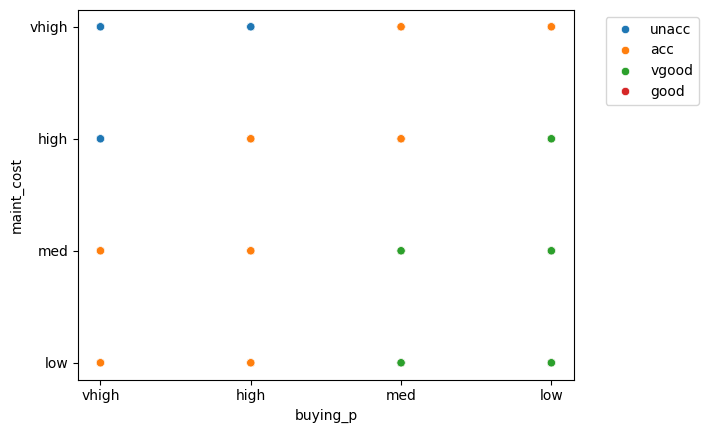

In [10]:
sns.scatterplot(x=data_frame["buying_p"], y=data_frame["maint_cost"], hue = data_frame["decision"])
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') #label'i grafigin disinda gostermek icin
plt.show()

### siniflar rahat ayrilacak gibi duruyor<br>Artik X, y ayrilmasina gecelim

In [11]:
X = data_frame.drop("decision", axis=1)
y = data_frame["decision"]

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=15)

## Ordinal Encoding

#### burda ise mesela low, high med gibi degerler ordinal encoding icim muqemmel bir secenek. sirayla 1 2 3 verebiliriz.

In [13]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### __ColumnTransformer__: Sana, bir veri setindeki sütunları ayırarak, her bir gruba özel bir dönüşüm (transform) işlemi uygulama esnekliği sunar.<br><br>Bir makine öğrenmesi projesinde genellikle şu adımları izlersin:<br>--Kategorik Sütunlar: OneHotEncoder veya LabelEncoder gibi bir yöntemle sayısal hale getirilmesi gerekir.<br>!*!!__ColumnTransformer__ olmadan bu işlemleri yapmak, her bir sütun grubunu ayrı ayrı seçip, ayrı ayrı dönüştürmek ve sonra bu verileri tekrar birleştirmek anlamına gelir. Bu, uzun ve hataya açık bir süreçtir.

In [14]:
data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1727 entries, 0 to 1726
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   buying_p    1727 non-null   object
 1   maint_cost  1727 non-null   object
 2   n_doors     1727 non-null   int64 
 3   n_persons   1727 non-null   int64 
 4   lug_boot    1727 non-null   object
 5   safety      1727 non-null   object
 6   decision    1727 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


### preprocessor = ColumnTransformer() --> shift + tab basip incelersek; <br> bizden "transformers" istiyor. List icinde tuple. Tuple'nin icinde de <br>1-bir isim veriyoruz istedigimiz<br>2- transformer veriyoruz yani encoder<br>3- columns yani hangi column'larda yapacagimizi soyluyoruz<br><br>__remainder__: default="drop"'tur. Eger "passthrough" yapmazsak, encode edilmeyen column'lari silebilir. O yuzden geri kalani ayni tutmasi icin passthrough yapmaliyiz.

In [15]:
X_train.columns

Index(['buying_p', 'maint_cost', 'n_doors', 'n_persons', 'lug_boot', 'safety'], dtype='object')

In [16]:
categorical_columns = ["buying_p","maint_cost","lug_boot","safety"]
num_columns = ["n_doors","n_persons"]

ordinal = OrdinalEncoder(categories=[
    # kucukten buyuge dogru siralanmalidir.
    
    ["low", "med", "high", "vhigh"], #buying icin
    ["low", "med", "high", "vhigh"], #maint_cost icin
    ["small", "med", "big"], #lug_boot icin
    ["low", "med", "high"] #safety icin
]) 
#auto default'dur kendi anlamaya calisir



#simdi transformer kullanimina bakalim,
preprocessor = ColumnTransformer(transformers=[
    ("transformation_ismi: ali", ordinal, categorical_columns)
    #("transformation_ismi: aybuke", label, label_col),
    #("transformation_ismi: karaduman", one_hat, one_hat_columns()
], remainder="passthrough")
#icerisinde istedigimiz kadar transformer koyabiliyoruz

X_train_transformer = preprocessor.fit_transform(X_train)
X_test_transformer = preprocessor.transform(X_test)

## Agac (Tree) Egitimi

In [17]:
from sklearn.tree import DecisionTreeClassifier #diyerek bi import edelim

[sklearn/decisionTree dokumantasyonuna gitmek icin tiklayiniz..](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html)

In [18]:
tree_model = DecisionTreeClassifier(criterion="gini", max_depth=3, random_state=0)

tree_model.fit(X_train_transformer, y_train)

y_pred1 = tree_model.predict(X_test_transformer)

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [20]:
import warnings
warnings.filterwarnings("ignore")

In [21]:
print(accuracy_score(y_test, y_pred1))
print(classification_report(y_test, y_pred1))
print(confusion_matrix(y_test, y_pred1))

0.7861271676300579
              precision    recall  f1-score   support

         acc       0.54      0.51      0.53       121
        good       0.00      0.00      0.00        21
       unacc       0.85      0.97      0.91       356
       vgood       0.00      0.00      0.00        21

    accuracy                           0.79       519
   macro avg       0.35      0.37      0.36       519
weighted avg       0.71      0.79      0.75       519

[[ 62   0  59   0]
 [ 21   0   0   0]
 [ 10   0 346   0]
 [ 21   0   0   0]]


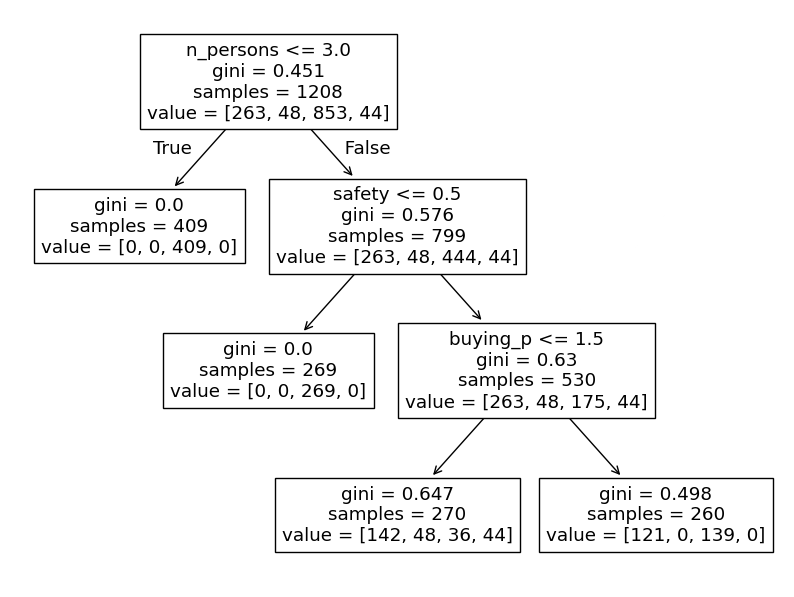

In [22]:
plt.figure(figsize=(10,7.5))
from sklearn import tree
feat_names = categorical_columns+ num_columns 
tree.plot_tree(tree_model.fit(X_train_transformer, y_train), feature_names=feat_names)
plt.show()

## Hyperparameter Tuning

In [23]:
parametreler={
    "criterion" : ["gini", "entropy", "log_loss"],
    "splitter" : ["best" ,"random"],
    "max_depth" : [1,2,3,4,5,6,7,8,9,10, None],
    "max_features" : ["log2", "sqrt", None]
}

In [24]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=parametreler, cv=5, scoring="accuracy")

In [25]:
grid.fit(X_train_transformer, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, None],
                         'max_features': ['log2', 'sqrt', None],
                         'splitter': ['best', 'random']},
             scoring='accuracy')

In [26]:
print(grid.best_params_)

{'criterion': 'log_loss', 'max_depth': None, 'max_features': None, 'splitter': 'best'}


In [27]:
y_pred2 = grid.predict(X_test_transformer)

print(accuracy_score(y_test, y_pred2))
print(classification_report(y_test, y_pred2))
print(confusion_matrix(y_test, y_pred2))

0.9730250481695568
              precision    recall  f1-score   support

         acc       0.91      0.98      0.94       121
        good       1.00      0.86      0.92        21
       unacc       1.00      0.97      0.99       356
       vgood       0.95      1.00      0.98        21

    accuracy                           0.97       519
   macro avg       0.97      0.95      0.96       519
weighted avg       0.97      0.97      0.97       519

[[119   0   1   1]
 [  3  18   0   0]
 [  9   0 347   0]
 [  0   0   0  21]]


In [28]:
tree_model_new = DecisionTreeClassifier(criterion="entropy", max_depth=10, max_features=None, splitter="best")

tree_model_new.fit(X_train_transformer, y_train)

y_pred3 = tree_model_new.predict(X_test_transformer)

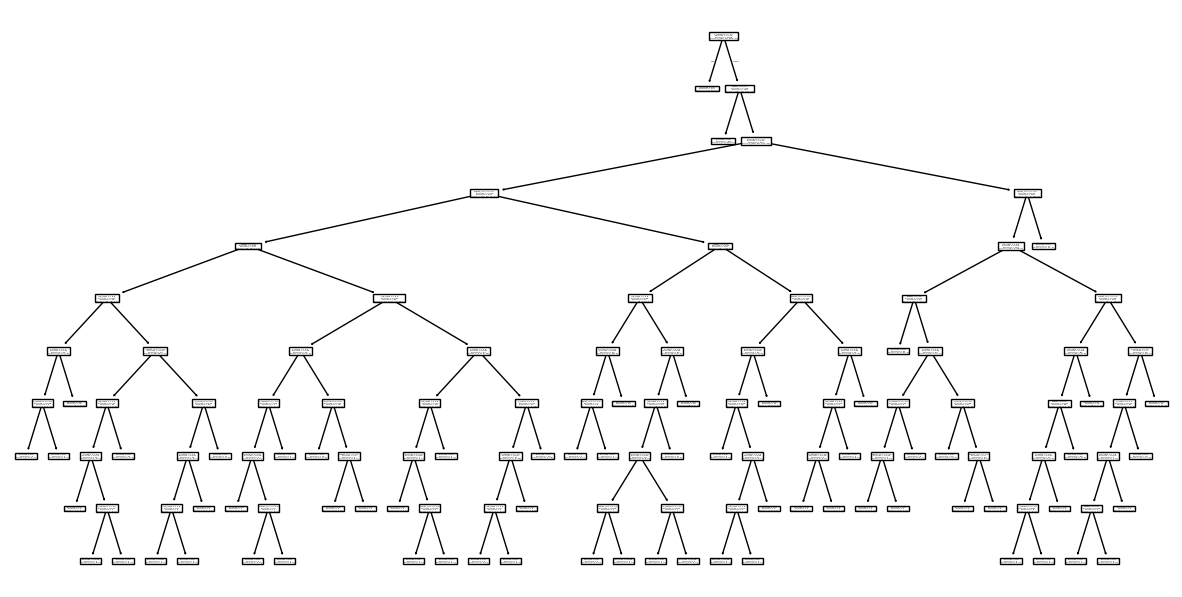

In [29]:
plt.figure(figsize=(15,7.5))
tree.plot_tree(tree_model_new.fit(X_train_transformer, y_train), feature_names=feat_names)
plt.show()

### Goruldugu gibi baya baya buyuk cikti agac :)

## Pruning (Iris dataseti ile)

In [30]:
df= pd.read_csv("Iris.csv")

In [31]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [32]:
X2 = df.drop(["Id", "Species"], axis=1)
y2 = df["Species"]

In [33]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.20, random_state=15)

In [34]:
tree2 = DecisionTreeClassifier()

In [35]:
tree2.fit(X2_train, y2_train)

DecisionTreeClassifier()

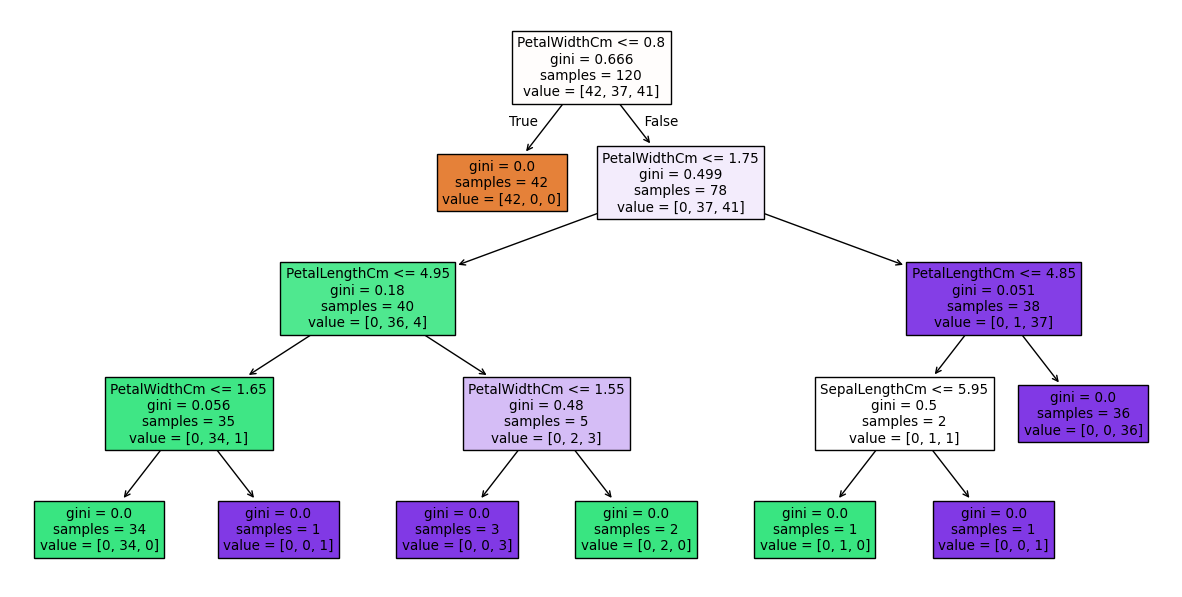

In [36]:
plt.figure(figsize=(15,7.5))


tree.plot_tree(tree2.fit(X2_train, y2_train), feature_names=X2_train.columns, filled=True) #filled renk icin
plt.show()

### aslinda petallenght'denn sonra filan fazla ayrilmis . Her bir kosul icin ayrilmis. bi yerden sonra dursak yeterli olur.

In [38]:
y_pred4 = tree2.predict(X2_test)

print(accuracy_score(y2_test, y_pred4))
print(classification_report(y2_test, y_pred4))
print(confusion_matrix(y2_test, y_pred4))

0.9666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        30
      macro avg       0.98      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30

[[ 8  0  0]
 [ 0 13  0]
 [ 0  1  8]]


In [43]:
tree3 = DecisionTreeClassifier(max_depth=3)

tree3.fit(X2_train, y2_train)

y_pred5 = tree3.predict(X2_test)

print(accuracy_score(y2_test, y_pred5))
print(classification_report(y2_test, y_pred5))
print(confusion_matrix(y2_test, y_pred5))

0.9666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         8
Iris-versicolor       0.93      1.00      0.96        13
 Iris-virginica       1.00      0.89      0.94         9

       accuracy                           0.97        30
      macro avg       0.98      0.96      0.97        30
   weighted avg       0.97      0.97      0.97        30

[[ 8  0  0]
 [ 0 13  0]
 [ 0  1  8]]


### bende accuracy de bir degisiklik olmadi budama islemi yapsam bile ama atil hocada olmustu:)

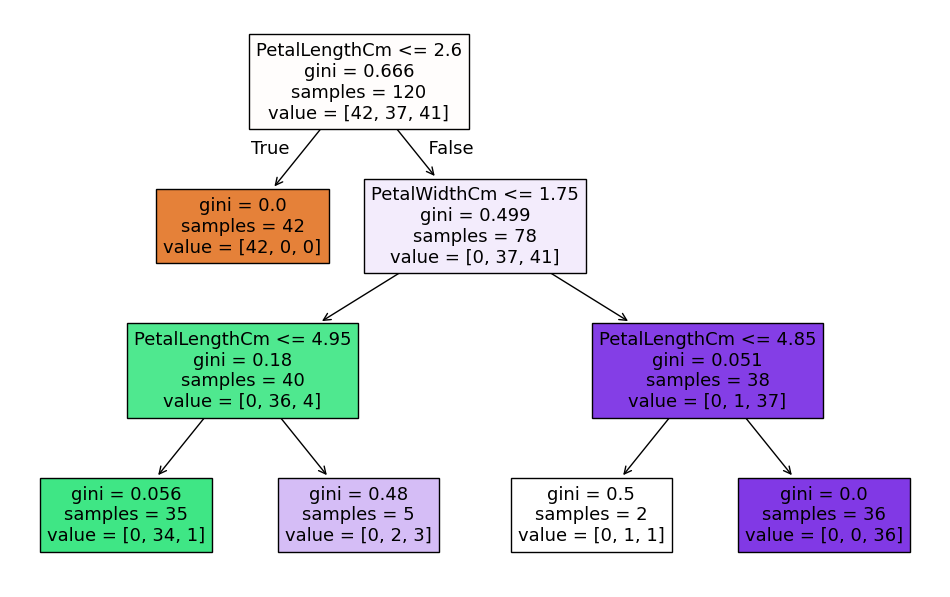

In [46]:
plt.figure(figsize=(12,7.5))


tree.plot_tree(tree3.fit(X2_train, y2_train), feature_names=X2_train.columns, filled=True) #filled renk icin
plt.show()